# Derivadas e gradientes numéricos

**Tema:** Álgebra Linear e Otimização › Cálculo e Gradiente Descendente

Antes de usar gradiente descendente, vale entender o que exatamente um
gradiente calcula — e como verificar, na unha, se uma derivada implementada
está correta. Este notebook usa apenas diferenças finitas: sem bibliotecas de
diferenciação simbólica, só a definição.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. A derivada como inclinação da reta tangente

f'(2.5) analítica         = 3.750000
f'(2.5) diferença finita  = 3.750000
diferença                 = 3.57e-11


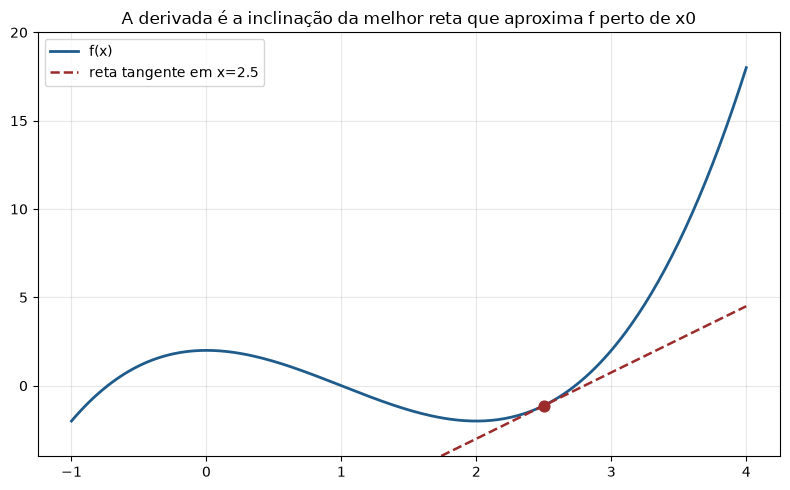

In [2]:
def f(x):
    return x**3 - 3 * x**2 + 2


def f_linha_analitica(x):
    return 3 * x**2 - 6 * x


x0 = 2.5
h = 1e-5
derivada_numerica = (f(x0 + h) - f(x0 - h)) / (2 * h)
derivada_exata = f_linha_analitica(x0)

print(f"f'({x0}) analítica         = {derivada_exata:.6f}")
print(f"f'({x0}) diferença finita  = {derivada_numerica:.6f}")
print(f"diferença                 = {abs(derivada_exata - derivada_numerica):.2e}")

x = np.linspace(-1, 4, 300)
tangente = f(x0) + derivada_exata * (x - x0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, f(x), color=AZUL, lw=2, label="f(x)")
ax.plot(x, tangente, color=VERMELHO, lw=1.8, ls="--",
        label=f"reta tangente em x={x0}")
ax.scatter([x0], [f(x0)], color=VERMELHO, zorder=5, s=60)
ax.set_ylim(f(x).min() - 2, f(x).max() + 2)
ax.set_title("A derivada é a inclinação da melhor reta que aproxima f perto de x0")
ax.legend(); plt.tight_layout(); plt.show()

## 2. Diferença finita central vs. progressiva: o efeito de h

A teoria diz que a central tem erro $O(h^2)$ e a progressiva tem erro
$O(h)$. Vamos medir isso variando $h$ e comparando com o valor exato.

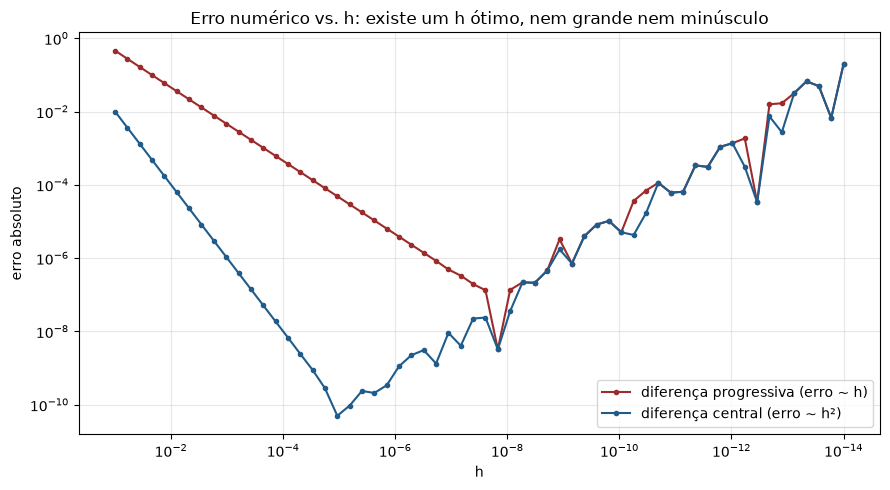

Para h muito pequeno (<~1e-8), o erro de arredondamento de ponto flutuante
domina e a curva volta a SUBIR — não adianta escolher h arbitrariamente pequeno.


In [3]:
def diferenca_progressiva(f, x, h):
    return (f(x + h) - f(x)) / h


def diferenca_central(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)


hs = np.logspace(-1, -14, 60)
erros_prog = [abs(diferenca_progressiva(f, x0, h) - derivada_exata) for h in hs]
erros_cent = [abs(diferenca_central(f, x0, h) - derivada_exata) for h in hs]

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(hs, erros_prog, "o-", ms=3, color=VERMELHO, label="diferença progressiva (erro ~ h)")
ax.loglog(hs, erros_cent, "o-", ms=3, color=AZUL, label="diferença central (erro ~ h²)")
ax.set_xlabel("h"); ax.set_ylabel("erro absoluto")
ax.set_title("Erro numérico vs. h: existe um h ótimo, nem grande nem minúsculo")
ax.invert_xaxis()
ax.legend(); plt.tight_layout(); plt.show()

print("Para h muito pequeno (<~1e-8), o erro de arredondamento de ponto flutuante")
print("domina e a curva volta a SUBIR — não adianta escolher h arbitrariamente pequeno.")

## 3. Gradiente: derivadas parciais empilhadas

Para $f(x, y) = x^2 + 3xy + y^2$, o gradiente analítico é
$\nabla f = (2x + 3y,\ 3x + 2y)$. Vamos verificar numericamente em vários
pontos.

In [4]:
def f2(v):
    x, y = v
    return x**2 + 3 * x * y + y**2


def grad_f2_analitico(v):
    x, y = v
    return np.array([2 * x + 3 * y, 3 * x + 2 * y])


def gradiente_numerico(f, v, h=1e-6):
    """Gradiente por diferença finita central, coordenada a coordenada."""
    grad = np.zeros_like(v, dtype=float)
    for i in range(len(v)):
        v_mais, v_menos = v.copy(), v.copy()
        v_mais[i] += h
        v_menos[i] -= h
        grad[i] = (f(v_mais) - f(v_menos)) / (2 * h)
    return grad


pontos_teste = [np.array([1.0, 1.0]), np.array([-2.0, 3.0]), np.array([0.5, -0.5])]
for v in pontos_teste:
    g_num = gradiente_numerico(f2, v)
    g_ana = grad_f2_analitico(v)
    print(f"ponto {v}:  numérico = {g_num}   analítico = {g_ana}   "
          f"erro = {np.linalg.norm(g_num - g_ana):.2e}")

ponto [1. 1.]:  numérico = [5. 5.]   analítico = [5. 5.]   erro = 2.68e-10
ponto [-2.  3.]:  numérico = [5.00000000e+00 1.77635684e-09]   analítico = [5. 0.]   erro = 1.91e-09
ponto [ 0.5 -0.5]:  numérico = [-0.5  0.5]   analítico = [-0.5  0.5]   erro = 1.44e-11


## 4. Visualizando o gradiente: sempre perpendicular às curvas de nível

Uma propriedade que vale memorizar: o gradiente em qualquer ponto é
**perpendicular** à curva de nível que passa por ali, e aponta para onde a
função cresce mais rápido.

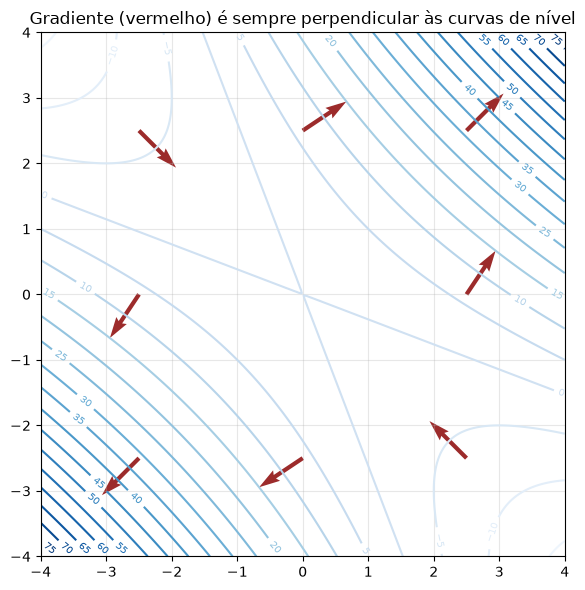

In [5]:
xx, yy = np.meshgrid(np.linspace(-4, 4, 200), np.linspace(-4, 4, 200))
zz = xx**2 + 3 * xx * yy + yy**2

fig, ax = plt.subplots(figsize=(7, 6))
cont = ax.contour(xx, yy, zz, levels=20, cmap="Blues")
ax.clabel(cont, inline=True, fontsize=7)

pontos_grade = [np.array([x_, y_]) for x_ in [-2.5, 0, 2.5] for y_ in [-2.5, 0, 2.5]
                if not (x_ == 0 and y_ == 0)]
for v in pontos_grade:
    g = grad_f2_analitico(v)
    g_normalizado = g / np.linalg.norm(g) * 0.8
    ax.quiver(*v, *g_normalizado, color=VERMELHO, angles="xy", scale_units="xy",
              scale=1, width=0.008)

ax.set_title("Gradiente (vermelho) é sempre perpendicular às curvas de nível")
ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 5. Gradiente da soma de quadrados: o gradiente que sustenta OLS

$f(\beta) = \|X\beta - y\|^2$ tem gradiente $\nabla f = 2X^\top(X\beta - y)$.
Vamos verificar numericamente contra a expressão analítica — este é
exatamente o gradiente que, igualado a zero, produz as equações normais do
módulo 1.

In [6]:
n, p = 100, 3
X = rng.normal(size=(n, p))
y = rng.normal(size=n)


def perda_minimos_quadrados(beta):
    residuo = X @ beta - y
    return residuo @ residuo


def grad_perda_analitico(beta):
    return 2 * X.T @ (X @ beta - y)


beta_teste = rng.normal(size=p)
grad_num = gradiente_numerico(perda_minimos_quadrados, beta_teste, h=1e-5)
grad_ana = grad_perda_analitico(beta_teste)

print("gradiente numérico :", grad_num)
print("gradiente analítico:", grad_ana)
print(f"erro relativo: {np.linalg.norm(grad_num - grad_ana) / np.linalg.norm(grad_ana):.2e}")

gradiente numérico : [-25.23609014  56.14513626 176.46516944]
gradiente analítico: [-25.23609014  56.14513626 176.46516944]
erro relativo: 1.54e-11


## 6. Encontrando onde o gradiente é zero: a solução fechada bate?

Se $\nabla f(\beta^*) = 0$ é a condição de mínimo, resolver essa equação para
a soma de quadrados deve reproduzir exatamente a fórmula de mínimos quadrados
do módulo 1.

In [7]:
beta_gradiente_zero = np.linalg.solve(X.T @ X, X.T @ y)  # resolve 2X'(X*beta - y) = 0
beta_lstsq = np.linalg.lstsq(X, y, rcond=None)[0]

print(f"beta (resolvendo grad=0 ):  {beta_gradiente_zero}")
print(f"beta (lstsq, referência) :  {beta_lstsq}")
print(f"diferença máxima         :  {np.abs(beta_gradiente_zero - beta_lstsq).max():.2e}")

grad_no_minimo = grad_perda_analitico(beta_gradiente_zero)
print(f"\n||gradiente no mínimo|| = {np.linalg.norm(grad_no_minimo):.2e}   <- deveria ser ~0")

beta (resolvendo grad=0 ):  [ 0.00256505  0.07011846 -0.20589623]
beta (lstsq, referência) :  [ 0.00256505  0.07011846 -0.20589623]
diferença máxima         :  5.55e-17

||gradiente no mínimo|| = 5.63e-15   <- deveria ser ~0


## O que levar deste notebook

- A derivada é a inclinação da melhor reta que aproxima $f$ localmente — e
  diferenças finitas a recuperam sem fórmula analítica.
- Diferença central converge mais rápido ($O(h^2)$) que progressiva
  ($O(h)$); ambas degradam para $h$ pequeno demais, por erro de ponto
  flutuante.
- O gradiente empilha derivadas parciais e aponta na direção de máximo
  crescimento — sempre perpendicular às curvas de nível.
- "Gradient checking" (comparar gradiente analítico com numérico) é a forma
  padrão de verificar se uma derivada foi implementada corretamente — a
  mesma técnica usada para depurar redes neurais no tema de Deep Learning.
- O gradiente da soma de quadrados, igualado a zero, **é** a fórmula de
  mínimos quadrados — otimização e álgebra linear são a mesma história vista
  de dois ângulos.

→ Próximo: **Gradiente descendente do zero**, quando não há fórmula fechada
para igualar o gradiente a zero.